Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
cl = ['r', 'g', 'b', 'c', 'm', 'y', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
t[[360.           1.05086957   1.74480626   4.        ]]
t[[400.           1.08412729   1.80857956   6.        ]]
t[[450.     1.24   1.57   8.  ]]
t[[490.           1.1282571    1.74498554  10.        ]]
t[[530.           1.17723814   1.68443586  12.        ]]
t[[570.           1.18964452   1.66433168  14.        ]]
t[[645.     0.84   2.27  16.  ]]
t[[650.           1.18526197   1.69636306  18.        ]]


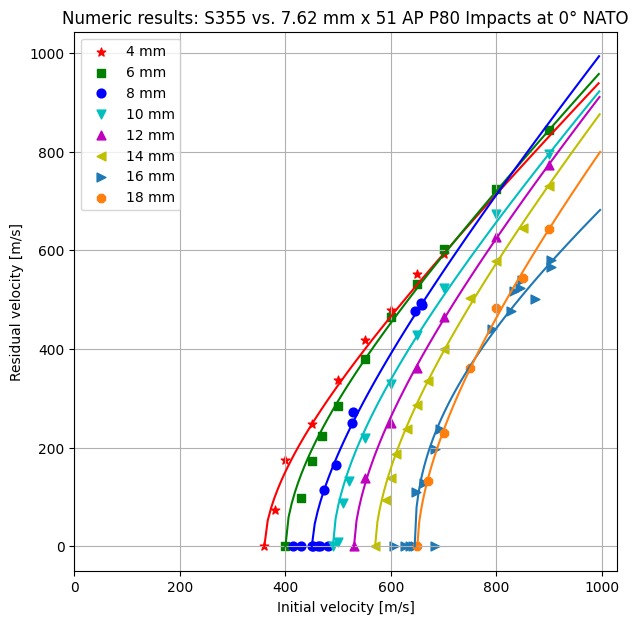

In [1]:
##############################
# Load and plot original data
# 2026-03-18_11-30-02 - tu są wyniki!!!
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import math
import pickle
import os
from datetime import datetime

from jupyter_server.utils import path2url
from pysr import PySRRegressor, TemplateExpressionSpec

#dane = np.genfromtxt('data/dane_2026-03-16.txt', delimiter=';', skip_header=1)
#wspolczynniki = np.genfromtxt('data/wspolczynniki_2026-03-16.txt', delimiter=';', skip_header=1)

#dane = np.genfromtxt('data/dane_2026-03-16.txt', delimiter=';', skip_header=1)
#wspolczynniki = np.genfromtxt('data/wspolczynniki_2026-03-16.txt', delimiter=';', skip_header=1)

dane = np.genfromtxt('data/dane_2026-03-17_exp_num.txt', delimiter=';', skip_header=1)
wspolczynniki = np.genfromtxt('data/wspolczynniki_2026-03-17_exp_num.txt', delimiter=';', skip_header=1)

def make_sequence(start_seq, end_seq, number_points):
    step = (end_seq - start_seq) / number_points
    vi_list = []
    a = 0
    actual_value = start_seq
    while a < number_points:
        actual_value = start_seq + a * step
        vi_list.append(actual_value)
        a = a + 1
    vi = np.array(vi_list)
    vi = np.sort(vi)
    return vi

def Vr(Vi, a, P, V_bl):
    res = np.zeros(Vi.shape[0])
    for id in range(Vi.shape[0]):
        p1 = math.pow(Vi[id], P) - math.pow(V_bl, P)
        if p1 > 0:
            p2 = a * math.pow(p1,1./P)
        else:
            p2 = 0
        res[id] = p2
    return res


plt.subplots(figsize=(7, 7))
#t = 18
color_list = ['r', 'g', 'b', 'c', 'm', 'y'] + list(mcolors.TABLEAU_COLORS.values())
markers = ["*", ",", "o", "v", "^", "<", ">", "8", "s", "p", "P", "h", "X", "D", "d"]
print('cl = ' + str(color_list))
id_color = 0
for t in range(4, 19, 2):
    wsp = wspolczynniki[wspolczynniki[:,3] == t]
    dd = dane[dane[:,2] == t]
    print('t' + str(wsp))
    #print(dd)
    vbl = wsp[0, 0]
    aa = wsp[0, 1]
    pp = wsp[0, 2]
    vi = make_sequence(vbl, 1000, 100)
    vir = Vr(vi, aa, pp, vbl)


    plt.scatter(dd[:,0], dd[:,1], c=color_list[id_color], label=str(t) + ' mm', marker=markers[id_color], s=40)
    #plt.plot(vi, vir, c=color_list[id_color], ls='-', label='RL,Vbl=%5.0f m/s, a=%5.2f, p=%5.1f' % tuple([vbl, aa,pp]))
    plt.plot(vi, vir, c=color_list[id_color], ls='-')
    id_color += 1
plt.xlabel('Initial velocity [m/s]')
plt.ylabel('Residual velocity [m/s]')
plt.title('Numeric results: S355 vs. 7.62 mm x 51 AP P80 Impacts at 0° NATO')
plt.xlim(xmin=0)
plt.legend()
plt.grid()

In [104]:
"""
###########################################3
# Symbolic regression for all thicknesses
data_l_X = []
data_l_y = []
for t in wspolczynniki[:,3].tolist():
    #dd = dane[dane[:,2] == t]
    wsp = wspolczynniki[wspolczynniki[:,3] == t]
    #print('t' + str(wsp))
    #print(dd)
    vbl = wsp[0, 0]
    aa = wsp[0, 1]
    pp = wsp[0, 2]
    vi = make_sequence(vbl, 1000, 100)
    vir = Vr(vi, aa, pp, vbl)
    XX_ = np.column_stack((vi, np.repeat(t,vi.shape[0])))
    data_l_X.append(XX_)
    data_l_y.append(vir)

XX_full = np.concatenate(data_l_X, axis=0)
y_full = np.concatenate(data_l_y, axis=0)
wspolczynniki_list = wspolczynniki[:,3].tolist()
"""

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math
import matplotlib.colors as mcolors
from prompt_toolkit.shortcuts import confirm
from tqdm import tqdm

def calculate_pdf(min_val, max_val, step, my_function, frac = [1,1,1]):
    frac = np.asarray(frac)
    if np.sum(frac) < 0.0001:
        frac = np.asarray([1,1,1])
    frac = frac / np.sum(frac)

    border_left = 10 * step
    border_right = 10 * step
    grid_help = np.mgrid[min_val-border_left:max_val+border_right:step]
    x = grid_help
    y = my_function(grid_help)
    y_grad = np.abs(np.gradient(y))
    y_grad2 = np.abs(np.gradient(y_grad))

    x_ = x[10:-10]
    y_ = y[10:-10]
    y_grad_ = y_grad[10:-10]
    y_grad2_ = y_grad2[10:-10]

    y_pdf = np.zeros(y_grad2_.shape)
    y_pdf[0] = frac[0] * step + frac[1] * y_grad_[0] + frac[2] * y_grad2_[0]

    for i in range(1, y_pdf.shape[0]):
        val = frac[0] * step + frac[1] * y_grad_[i] + frac[2] * y_grad2_[i]
        y_pdf[i] = y_pdf[i-1] + val

    y_pdf_max = np.max(y_pdf)
    y_pdf /= y_pdf_max
    return (y_pdf, x_, y_, y_grad_, y_grad2_)

def plot_pdf(y_pdf, x_, y_, y_grad_, y_grad2_):
    plt.plot(x_, y_, color='r')
    plt.show()
    plt.plot(x_, y_grad_, color='b')
    plt.show()
    plt.plot(x_, y_grad2_, color='g')
    plt.show()
    plt.plot(x_, y_pdf, color='y')
    plt.show()

def sample_from_pdf(y_pdf, x_, y_, sample_size):
    r_n = np.random.rand(sample_size)
    rx = np.zeros(sample_size)
    ry = np.zeros(sample_size)
    for i in range(len(r_n)):
        a = 0
        while r_n[i] > y_pdf[a]:
            a += 1
        rx[i] = x_[a]
        ry[i] = y_[a]
    return rx, ry

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


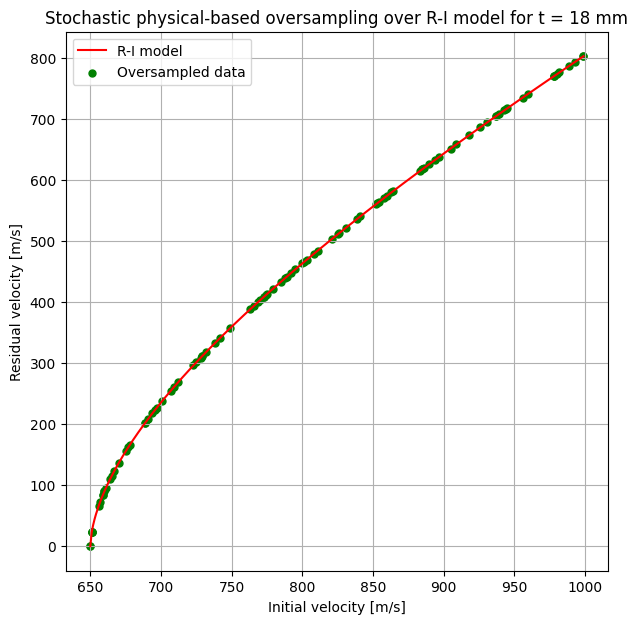

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


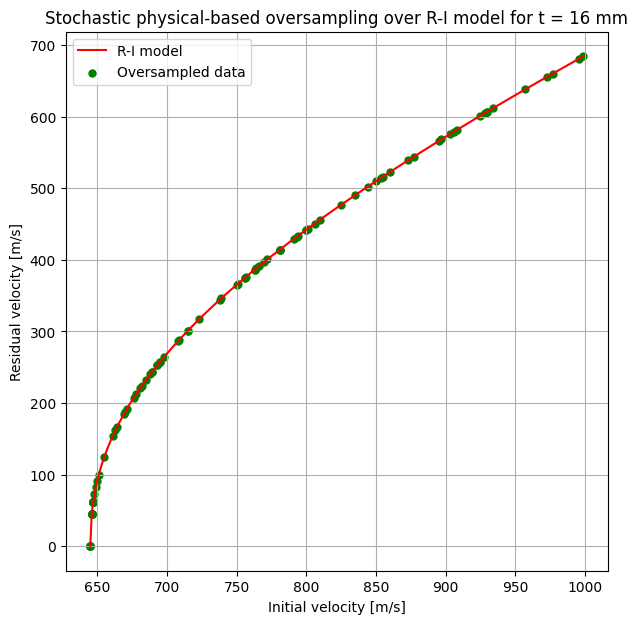

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


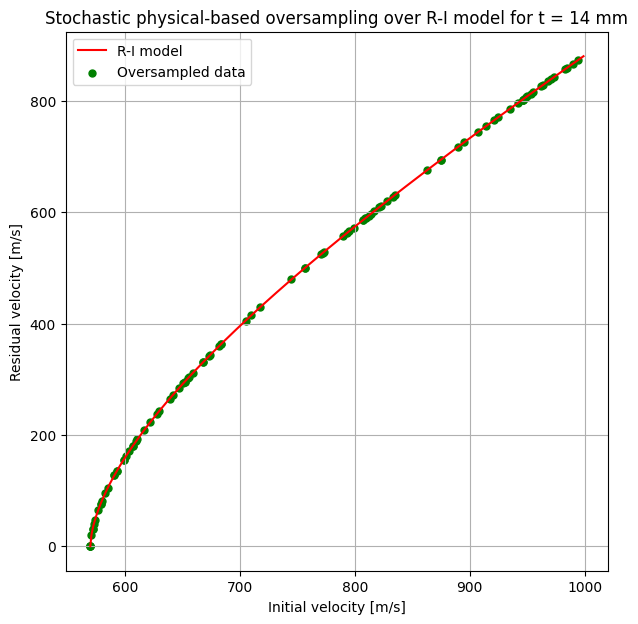

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


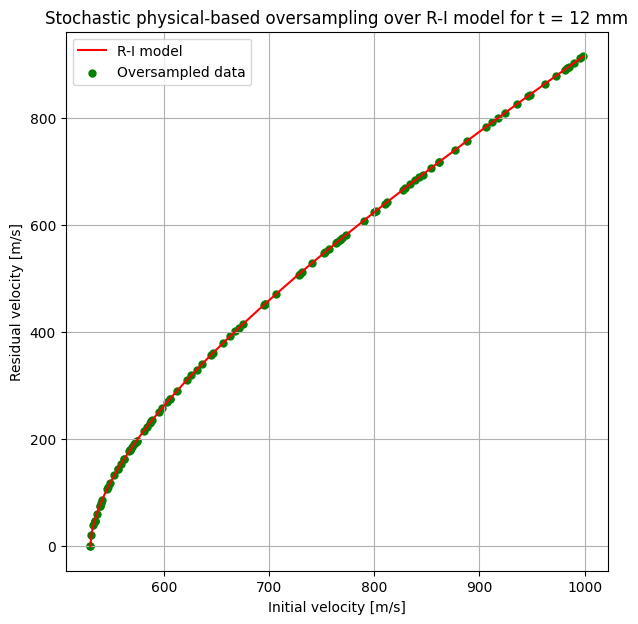

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


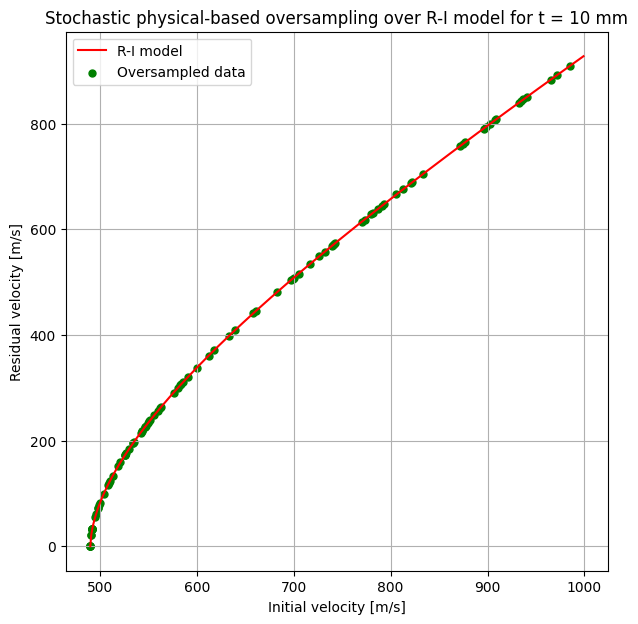

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


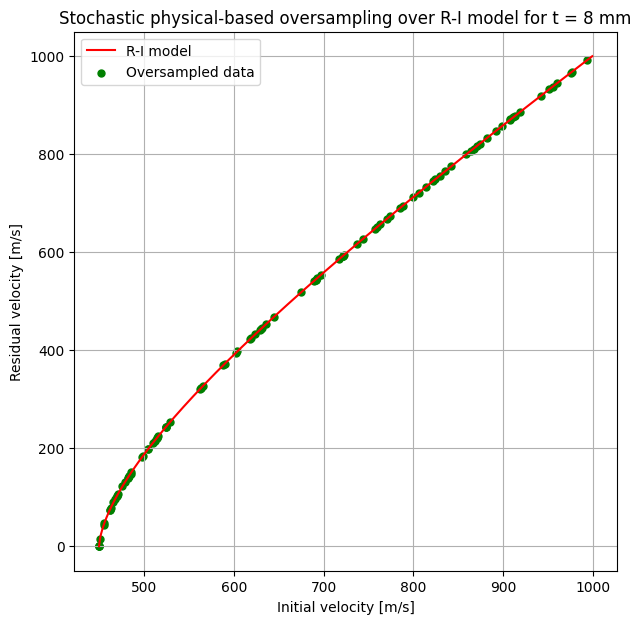

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


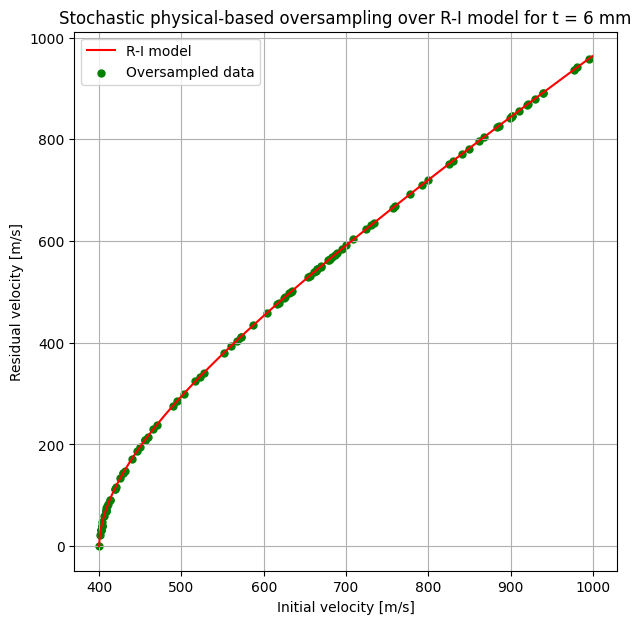

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


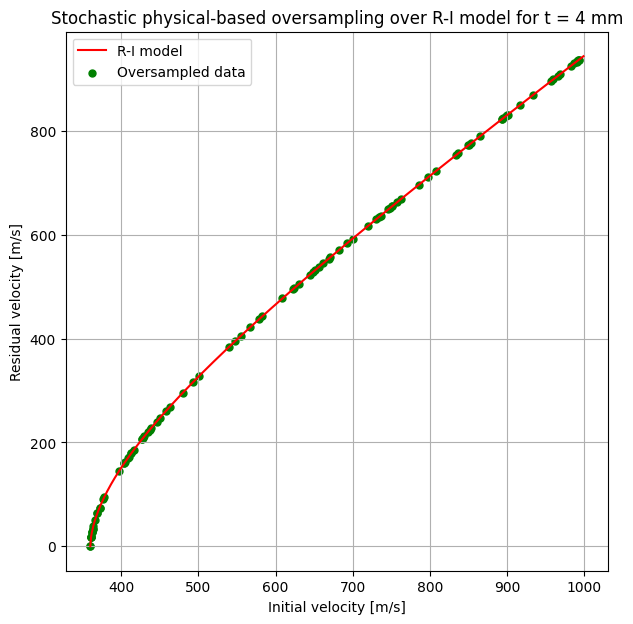

In [3]:
dane_extended = []
sample_size = 100
max_val = 1000
step = 1
frac = 0.99
frac = 0.5
#frac = [1, 0, 0]
#frac = [1, 1, 1]
#frac = [0, 0.01, 0.99]
#NOWE
#frac = [0, 0.5, 0.5]
#NOWE
frac = [0, 0.25, 0.75]
#frac = [0, 0, 1]

wspolczynniki_list = wspolczynniki[:,3].tolist()

full_data = []

for thickness in wspolczynniki_list:
    wsp = wspolczynniki[wspolczynniki[:,3] == thickness]
    vbl = wsp[0, 0]
    aa = wsp[0, 1]
    pp = wsp[0, 2]
    grid_help = np.mgrid[vbl-10:max_val:step]

    def function_helper(grid):
        y = Vr(grid, aa, pp, vbl)
        return y


    (y_pdf, x_, y_, y_grad_, y_grad2_) = calculate_pdf(vbl, 1000, 1, function_helper, frac)
    #plot_pdf(y_pdf, x_, y_, y_grad_, y_grad2_)
    rx, ry = sample_from_pdf(y_pdf, x_, y_, sample_size)

    #which_to_find_bool = np.abs(data_full[:,1] - thickness) < 0.0001
    #data_help = data_full[which_to_find_bool]

    fig, ax = plt.subplots(figsize=(7, 7))
    plt.plot(x_, y_, color='r', label='R-I model')
    plt.scatter(rx, ry, marker='.', color='g', label='Oversampled data', s=100)
    #plt.scatter(data_help[:,0], data_help[:,2], marker='.', color='b')
    plt.title('Stochastic physical-based oversampling over R-I model for t = ' + str(int(thickness)) + " mm")


    #plt.title("SR on test data t = " + str(int(t)) + " mm" + ", Vbl = " + str(int(vbl_)) + " m/s, est. Vbl = " + str(int(vbl(t))) + " m/s")

    #plt.title("Prediction on test dataset t = " + str(int(t)) + " mm" + ", Vbl = " + str(int(vbl_)) + ", estimated Vbl = XXX")
    #ax.plot(vi_, vr_list, c=color_list[id_color + 1], ls='-', label='SR approximation')

    plt.xlabel('Initial velocity [m/s]')
    plt.ylabel('Residual velocity [m/s]')

    ax.legend()
    plt.grid()

    plt.savefig("./figures/oversampling_" + str(int(thickness)) + ".eps", dpi=300, format='eps', bbox_inches="tight")
    plt.show()



    numeric_series = np.array([rx, np.repeat(thickness, sample_size), ry]).transpose()
    full_data.extend(numeric_series)
    #dane_extended = np.concatenate((dane_extended, numeric_series))



full_data_numpy = np.array(full_data)

#np.savetxt('full_data_numpy_025_075.csv', full_data_numpy)
full_data_numpy = np.loadtxt('full_data_numpy_025_075.csv')
XX_full = full_data_numpy[:,0:2]
y_full = full_data_numpy[:,2]


In [4]:
XX_full

array([[757.,  18.],
       [973.,  18.],
       [760.,  18.],
       ...,
       [509.,   4.],
       [770.,   4.],
       [425.,   4.]], shape=(800, 2))

In [5]:
folder_name = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Utwórz katalog
os.makedirs("./results/" + folder_name, exist_ok=True)

print(f"Output directory: {folder_name}")


Output directory: 2026-03-18_11-30-02


In [7]:
def train_symbolic_regressor(XX_full_train, y_full_train):
    template = TemplateExpressionSpec(
        expressions=["p","a","vbl"],
        variable_names=["v", "t"],
        combine="(v^p(t) - vbl(t)^p(t))^(1/p(t))*a(t)",
    )

    model = PySRRegressor(
        #expression_spec = template,
        maxsize=30,
        populations=100,
        population_size=100,
        precision=64,
        #constraints={'^': (-1, 1)},
        constraints={'^': (-1, 3)},
        niterations=30,  # < Increase me for better results
        binary_operators=["+", "*", "^","/"],
        unary_operators=["square", "log", "cube", "log10", "log2", "sqrt", "log1p", "inv"],
        elementwise_loss="loss(prediction, target) = (prediction - target)^2",
        early_stop_condition=(
            "stop_if(loss, complexity) = loss < 1.8e+02 && complexity <= 12"
            # Stop early if we find a good and simple equation
        ),
        # ^ Custom loss function (julia syntax),
    )
    model.fit(XX_full_train, y_full_train)
    return model


In [8]:
for t in wspolczynniki_list:
    print("Thickness: " + str(t) + " mm")
    XX_full_train_ids = XX_full[:, 1] != t
    XX_full_test_ids = XX_full[:, 1] == t

    XX_full_train = XX_full[XX_full_train_ids]
    XX_full_test = XX_full[XX_full_test_ids]
    y_full_train = y_full[XX_full_train_ids]
    y_full_test = y_full[XX_full_test_ids]

    np.savetxt('./results/test_folder/XX_full_train_' + str(t) + '.csv', XX_full_train)
    np.savetxt('./results/test_folder/XX_full_test_' + str(t) + '.csv', XX_full_test)
    np.savetxt('./results/test_folder/y_full_train_' + str(t) + '.csv', y_full_train)
    np.savetxt('./results/test_folder/y_full_test_' + str(t) + '.csv', y_full_test)

    out_model = train_symbolic_regressor(XX_full_train, y_full_train)
    path_help = './results/' + folder_name + '/sr_model_t=' + str(t) + '.pkl'

    with open(path_help, 'wb') as file:
        pickle.dump(out_model, file)


D:\Projects\Python\PycharmProjects\WebScrapper\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...


Thickness: 18.0 mm


[ Info: Started!



Expressions evaluated per second: 2.110e+05
Progress: 198 / 3000 total iterations (6.600%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.810e+04  0.000e+00  y = 427.62
3           2.219e+04  6.292e-01  y = x₀ + -258.07
4           1.691e+04  2.717e-01  y = square(x₀ * 0.029917)
5           1.555e+04  8.396e-02  y = x₀ + (x₁ * -25.128)
7           1.284e+04  9.560e-02  y = ((x₁ * -30.958) + x₀) / 0.83681
9           1.017e+04  1.167e-01  y = ((x₀ / 0.80174) + -124.24) + (x₁ / -0.038648)
11          4.426e+03  4.159e-01  y = ((((x₁ / -0.078418) + x₀) + -135.41) * 1.6724) + -282....
                                      7
13          2.982e+03  1.975e-01  y = (x₀ * 1.6626) + (cube(log2(4.9468 / x₁) * 4.0953) + -5...
                                      93.11)
14          2.902e+

[ Info: Final population:
[ Info: Results saved to:
D:\Projects\Python\PycharmProjects\WebScrapper\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


...

───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.535e+04  0.000e+00  y = 411.8
3           2.393e+04  5.735e-01  y = x₀ + -292.44
4           1.957e+04  2.011e-01  y = square(x₀) * 0.000832
5           1.727e+04  1.253e-01  y = x₀ + (x₁ * -24.221)
6           1.478e+04  1.558e-01  y = square(x₁ + (x₀ * -0.043232))
7           6.430e+03  8.321e-01  y = ((x₁ * -17922) / x₀) + x₀
9           3.219e+03  3.460e-01  y = x₀ + (x₁ / ((x₀ ^ 1.8189) / -3.6651e+06))
10          3.015e+03  6.546e-02  y = x₀ + ((x₁ * (inv(x₀) + -0.00069935)) * -34484)
11          2.405e+03  2.260e-01  y = (x₀ + (x₁ / ((x₀ ^ 1.683) / -1.8884e+06))) + 83.462
13          1.439e+03  2.568e-01  y = (x₀ + -47.984) + (cube(x₁ + 6.6438) * cube(-220.18 / x...
                                      ₀))
15          1.408e+03  1.088e-02  y = (x₀ + ((cube(x₁ + 4.8088) + x₀) * cube(-236.13 / x₀)))...
                       

[ Info: Started!



Expressions evaluated per second: 9.940e+04
Progress: 132 / 3000 total iterations (4.400%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.481e+04  0.000e+00  y = 421.1
3           2.451e+04  5.579e-01  y = x₀ + -290.29
5           1.648e+04  1.986e-01  y = x₀ + (x₁ / -0.041596)
7           1.642e+04  1.797e-03  y = (cube(log10(x₀)) + -13.328) ^ 2.606
9           3.267e+03  8.072e-01  y = ((x₁ * -31.189) + (x₀ * 1.7701)) + -463.89
19          1.307e+03  9.165e-02  y = (x₁ / (((x₁ + (log2(log10(x₀)) + (x₀ * -0.086243))) + ...
                                      13.835) * 0.0012065)) + (x₀ / 0.94537)
───────────────────────────────────────────────────────────────────────────────────────────────────
═════════════════════════════════════════════════════════════════════════════════

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.481e+04  0.000e+00  y = 421.1
3           2.451e+04  5.579e-01  y = x₀ + -290.29
4           1.732e+04  3.473e-01  y = cube(x₀) * 1.0009e-06
5           1.648e+04  4.990e-02  y = (x₁ / -0.041634) + x₀
7           6.161e+03  4.918e-01  y = x₀ + ((x₁ / x₀) * -17704)
8           3.757e+03  4.947e-01  y = x₀ + (x₁ * (-1.1584e+07 / square(x₀)))
9           2.184e+03  5.425e-01  y = (x₀ * 1.2097) + ((x₁ * -25389) / x₀)
11          1.756e+03  1.091e-01  y = x₀ + ((x₁ / ((x₀ + -199.04) * -5.5938e-05)) + 154.47)
13          1.383e+03  1.195e-01  y = x₀ + (x₁ / (((x₁ + 14.493) + (x₀ * -0.070896)) * 0.002...
                                      0762))
14          1.382e+03  5.489e-04  y = x₀ + (x₁ / (log1p(((x₀ * -0.073936) + x₁) * 0.0018224)...
                                       + 0.02771))
15          1.293e+03  6.637e-02  y = ((x₁ / (

In [5]:
path_help

NameError: name 'path_help' is not defined

In [10]:
#out_model.equations_.to_csv("xxx.csv", index=False, encoding="utf-8", sep="\t")
dir_help = './results/' + folder_name + '/'
all_files = os.listdir(dir_help)
for file_name in all_files:
    full_path = os.path.join(dir_help, file_name)
    if os.path.isfile(full_path) and file_name.lower().endswith(".pkl"):
        print(full_path)
        with open(full_path, 'rb') as file:
            # Load the pickled data
            loaded_model = pickle.load(file)
            loaded_model.equations_.to_csv(dir_help + file_name + ".csv", index=False, encoding="utf-8", sep="\t")

./results/2026-03-18_11-30-02/sr_model_t=10.0.pkl
./results/2026-03-18_11-30-02/sr_model_t=12.0.pkl
./results/2026-03-18_11-30-02/sr_model_t=14.0.pkl
./results/2026-03-18_11-30-02/sr_model_t=16.0.pkl
./results/2026-03-18_11-30-02/sr_model_t=18.0.pkl
./results/2026-03-18_11-30-02/sr_model_t=4.0.pkl
./results/2026-03-18_11-30-02/sr_model_t=6.0.pkl
./results/2026-03-18_11-30-02/sr_model_t=8.0.pkl


In [105]:
# for unfirom distribution
def get_params_for_thickness(t):
    p = 1
    a = 1
    vbl = 1
    if t == 4:
        p = lambda x: (-1.5507760900115786 / x) + 1.7684375679231885
        a = lambda x : 1.178036908261981
        vbl = lambda x : (x * 21.11285465317287) + 269.96723313976764
    if t == 6:
        p = lambda x: 1.6082325699904603
        a = lambda x : math.pow(1, 0.0736795568697973)
        vbl = lambda x : (x * 20.699050689985967) + 277.1963476344057
    if t == 8:
        p = lambda x: math.pow(x, 0.14515048595684368) + 0.1558834893281958
        a = lambda x : 1.1958015250694984
        vbl = lambda x : (x * 21.982450727028972) + 254
    if t == 10:
        p = lambda x: 1.5580116935676922
        a = lambda x : math.log10((x * 0.48907085872105316) + 11.03366949942125)
        vbl = lambda x : (x + 12.495122101150363) * 21.306336323728694
    if t == 12:
        p = lambda x: math.pow(x, 0.16725005580779143)
        a = lambda x : 1.2326235450489995
        vbl = lambda x : (x + 10.095456012973099) * 23.135099810554383
    if t == 14:
        p = lambda x: math.sqrt(math.log10(x) + 1.676846614447631)
        a = lambda x : 1.158683389792202
        vbl = lambda x : math.pow((x + 29.455497228507785), 1.676846614447631)
    if t == 16:
        p = lambda x: 1.538292534665321
        a = lambda x : math.pow(1.1730428578939813, math.log10(x))
        vbl = lambda x : (x / 0.044087339435773004) + 238.36083914732652
    if t == 18:
        p = lambda x: math.log10(math.log(x)) + 1.2983245945625426
        a = lambda x : 1.1510833668425169
        vbl = lambda x : (x * 21.58567170444433) + 264.6279901178961

    return (p, a, vbl)

def vr_(v, t, p, a, vbl):
    part1 = math.pow(v,p(t)) - math.pow(vbl(t),p(t))
    if part1 > 0:
        return math.pow(part1, 1/p(t)) * a(t)
    else:
        return 0



In [33]:
# distribution 0 0.01 0.99

def cube(x):
    return math.pow(x, 3)

def square(x):
    return math.pow(x, 2)

def get_params_for_thickness(t):
    p = 1
    a = 1
    vbl = 1
    if t == 4:
        # p = 1.2707477732405137; a = log10(#1 + 20.42465892007432); vbl = cube(log(cube((#1 + 11.831756788810187) ^ 0.8499695671418912)))
        p = lambda x: 1.2707477732405137
        a = lambda x : math.log10(x + 20.42465892007432)
        vbl = lambda x : cube(math.log(cube(math.pow((x + 11.831756788810187), 0.8499695671418912))))
    if t == 6:
        # p = 1.0935564682932424; a = sqrt(log2(#1)); vbl = sqrt((#1 + 1.0939508245543033) / 4.679271662193321e-5)
        p = lambda x: 1.0935564682932424
        a = lambda x : math.sqrt(math.log2(x))
        vbl = lambda x : math.sqrt((x + 1.0939508245543033) / 4.679271662193321e-5)
    if t == 8:
        #1.321752275957436; a = #1 ^ 0.1469269911008023; vbl = (#1 * 20.977429777694137) + 272.40478201054714
        p = lambda x: 1.321752275957436
        a = lambda x : math.pow(x, 0.1469269911008023)
        vbl = lambda x : (x * 20.977429777694137) + 272.40478201054714
    if t == 10:
        #p = 1.2202059191036054; a = sqrt(log1p(#1)); vbl = (#1 / 0.046842088997013684) + 265.70781273118354
        p = lambda x: 1.2202059191036054
        a = lambda x : math.sqrt(math.log1p(x))
        vbl = lambda x : (x / 0.046842088997013684) + 265.70781273118354
    if t == 12:
        #p = 1.2254101470077692; a = sqrt(log1p(#1)); vbl = (#1 * 20.915526253720472) + 273.5197812841737
        p = lambda x: 1.2254101470077692
        a = lambda x : math.sqrt(math.log1p(x))
        vbl = lambda x : (x * 20.915526253720472) + 273.5197812841737
    if t == 14:
        # p = 1.2239656813337807; a = sqrt(log1p(#1)); vbl = log1p(#1 + 21.676135257292184) ^ 4.9447917278733255
        p = lambda x: 1.2239656813337807
        a = lambda x : math.sqrt(math.log1p(x))
        vbl = lambda x : math.pow(math.log1p(x + 21.676135257292184), 4.9447917278733255)
    if t == 16:
        #p = #1 ^ 0.15169802304145838; a = 1.3293305085689204; vbl = (#1 * 20.833456304449992) + 274.9964993134428
        p = lambda x: math.pow(x, 0.15169802304145838)
        a = lambda x : 1.3293305085689204
        vbl = lambda x : (x * 20.833456304449992) + 274.9964993134428
    if t == 18:
        # p = 1.0965065054155894; a = sqrt(sqrt(#1)); vbl = (#1 * 23.293862292157517) + 243.88585017220512
        p = lambda x: 1.0965065054155894
        a = lambda x : math.sqrt(math.sqrt(x))
        vbl = lambda x : (x * 23.293862292157517) + 243.88585017220512

    return (p, a, vbl)

def vr_(v, t, p, a, vbl):
    part1 = math.pow(v,p(t)) - math.pow(vbl(t),p(t))
    if part1 > 0:
        return math.pow(part1, 1/p(t)) * a(t)
    else:
        return 0



In [4]:
# distribution 0, 0.25, 0.75

def cube(x):
    return math.pow(x, 3)

def square(x):
    return math.pow(x, 2)

def get_params_for_thickness(t):
    p = 1
    a = 1
    vbl = 1
    if t == 4:
        # p = 1.5605645868498481; a = 1.198838040976907; vbl = (#1 * 20.83977045019187) + 274.8828696056518
        p = lambda x: 1.5605645868498481
        a = lambda x : 1.198838040976907
        vbl = lambda x : (x * 20.83977045019187) + 274.8828696056518
    if t == 6:
        # p = 1.4716183740781843; a = #1 ^ 0.09862155442612726; vbl = (#1 + 12.957462978465221) / 0.04762822572258125
        p = lambda x: 1.4716183740781843
        a = lambda x : math.pow(x, 0.09862155442612726)
        vbl = lambda x : (x + 12.957462978465221) / 0.04762822572258125
    if t == 8:
        # p = 1.5337089448595322; a = #1 ^ 0.07982204182064179; vbl = (#1 + 12.696981118708871) * 21.17466689316614
        p = lambda x: 1.5337089448595322
        a = lambda x : math.pow(x, 0.07982204182064179)
        vbl = lambda x : (x + 12.696981118708871) * 21.17466689316614
    if t == 10:
        # p = 1.4940632035957044; a = #1 ^ 0.09139616752493382; vbl = (#1 / 0.04666991664171184) + 264.29945874980416
        p = lambda x: 1.4940632035957044
        a = lambda x : math.pow(x, 0.09139616752493382)
        vbl = lambda x : (x / 0.04666991664171184) + 264.29945874980416
    if t == 12:
        # p = 1.5897076420665368; a = 1.1660489616315415; vbl = (#1 * 20.829716280157456) + 275.0200476635551
        p = lambda x: 1.5897076420665368
        a = lambda x : 1.1660489616315415
        vbl = lambda x : (x * 20.829716280157456) + 275.0200476635551
    if t == 14:
        # p = (#1 + -1.8794599788193975) * (1.5409724184687126 / (#1 + -1.6629993594920005)); a = 1.2259290538825467; vbl = (#1 + 12.808488439502135) * 21.096397567852364
        p = lambda x: (x + -1.8794599788193975) * (1.5409724184687126 / (x + -1.6629993594920005))
        a = lambda x : 1.2259290538825467
        vbl = lambda x : (x + 12.808488439502135) * 21.096397567852364
    if t == 16:
        # p = 1.6008791747417752; a = #1 ^ 0.07831768870647768; vbl = (#1 * 20.834204424441975) + 274.9678693890422
        p = lambda x: 1.6008791747417752
        a = lambda x : math.pow(x, 0.07831768870647768)
        vbl = lambda x : (x * 20.834204424441975) + 274.9678693890422
    if t == 18:
        # p = 1.4600388763283796; a = 1.252629287938389 ^ log10(#1); vbl = square(#1 + 1.5092063759037806) + 329.46359117116464
        p = lambda x: 1.4600388763283796
        a = lambda x : math.pow(1.252629287938389, math.log10(x))
        vbl = lambda x : square(x + 1.5092063759037806) + 329.46359117116464

    return (p, a, vbl)

def vr_(v, t, p, a, vbl):
    part1 = math.pow(v,p(t)) - math.pow(vbl(t),p(t))
    if part1 > 0:
        return math.pow(part1, 1/p(t)) * a(t)
    else:
        return 0

def vr_vt(v, t):
    val = 0
    try:
        # 9	2183.8349915043214	(x0 * 1.2096618277255398) + ((x1 * -25389.28257744158) / x0)
        # 11	1755.8777924922913	x0 + ((x1 / ((x0 + -199.0408209915172) * -5.5938017240840305e-5)) + 154.4708841258304)
        # 14	1381.9385278369327	x0 + (x1 / (log1p(((x0 * -0.07393643431418852) + x1) * 0.0018224248951987346) + 0.027709544925480396))
        if t == 4:
            val = (v * 1.2096618277255398) + ((t * -25389.28257744158) / v)
            #val = v + ((t / ((v + -199.0408209915172) * -5.5938017240840305e-5)) + 154.4708841258304)
        # 13	1438.8091845256322	(x0 + -47.984480077479546) + (cube(x1 + 6.643754211877821) * cube(-220.18322735030782 / x0))
        if t == 6:
            val = (v + -47.984480077479546) + (cube(t + 6.643754211877821) * cube(-220.18322735030782 / v))
        # 17	1398.9352523193356	((((106.93128571077212 ^ (215.23586579908726 / x0)) + -1.5662512031816072) * (5.784722146396231 ^ square(log10(x1)))) * -12.32365933371237) + x0
        if t == 8:
            val = ((math.pow(106.93128571077212, (215.23586579908726 / v)) + -1.5662512031816072) * (math.pow(5.784722146396231 , square(math.log10(t)))) * -12.32365933371237) + v
            #val = (v * 1.3158451707044234) + ((t * ((-532.3113762873243 / (v + -312.90643654125046)) * t)) + -292.5440430187787)
        # 14	1949.1455282309737	(x1 + 9.82096747091166) * ((x0 * (5.149337015229913 / (x1 + sqrt(x0)))) + -74.66231975257921)
        if t == 10:
            val = (t + 9.82096747091166) * ((v * (5.149337015229913 / (t + math.sqrt(v)))) + -74.66231975257921)
        # 13	1519.8655424343456	((x0 + ((x1 * -20.900877095064732) + -273.7825463552871)) * (x1 + 34.45180849864399)) ^ 0.6778660152879092
        if t == 12:
            val = math.pow(((v + ((t * -20.900877095064732) + -273.7825463552871)) * (t + 34.45180849864399)), 0.6778660152879092)
        # 10	1967.1661028509764	log(x0 + ((-19.76134489018952 * x1) + -279.9534151335569)) ^ 3.6938231821718426
        if t == 14:
            val = math.pow(math.log(v + ((-19.76134489018952 * t) + -279.9534151335569)), 3.6938231821718426)
        # 9	1647.9853019489435	(x1 * ((-34814.32199619825 / x0) + 26.36595391540375)) + x0
        if t == 16:
            val = (t * ((-34814.32199619825 / v) + 26.36595391540375)) + v
        # 11	1854.8389185876515	(((x1 * -20.632933076088825) + (x0 + -276.2018692228573)) ^ 0.6837562057574527) * 12.438328800753416
        if t == 18:
            val = (math.pow(((t * -20.632933076088825) + (v + -276.2018692228573)), 0.6837562057574527)) * 12.438328800753416
        if val < 0:
            return 0
        return val
    except ValueError as e:
        return 0
    except OverflowError as e:
        return 0

def vr_vt_t0(v, t, t0):
    val = 0
    try:
        # 9	2183.8349915043214	(x0 * 1.2096618277255398) + ((x1 * -25389.28257744158) / x0)
        # 11	1755.8777924922913	x0 + ((x1 / ((x0 + -199.0408209915172) * -5.5938017240840305e-5)) + 154.4708841258304)
        # 14	1381.9385278369327	x0 + (x1 / (log1p(((x0 * -0.07393643431418852) + x1) * 0.0018224248951987346) + 0.027709544925480396))
        if t0 == 4:
            val = (v * 1.2096618277255398) + ((t * -25389.28257744158) / v)
            #val = v + ((t / ((v + -199.0408209915172) * -5.5938017240840305e-5)) + 154.4708841258304)
        # 13	1438.8091845256322	(x0 + -47.984480077479546) + (cube(x1 + 6.643754211877821) * cube(-220.18322735030782 / x0))
        if t0 == 6:
            val = (v + -47.984480077479546) + (cube(t + 6.643754211877821) * cube(-220.18322735030782 / v))
        # 17	1398.9352523193356	((((106.93128571077212 ^ (215.23586579908726 / x0)) + -1.5662512031816072) * (5.784722146396231 ^ square(log10(x1)))) * -12.32365933371237) + x0
        if t0 == 8:
            val = ((math.pow(106.93128571077212, (215.23586579908726 / v)) + -1.5662512031816072) * (math.pow(5.784722146396231 , square(math.log10(t)))) * -12.32365933371237) + v
            #val = (v * 1.3158451707044234) + ((t * ((-532.3113762873243 / (v + -312.90643654125046)) * t)) + -292.5440430187787)
        # 14	1949.1455282309737	(x1 + 9.82096747091166) * ((x0 * (5.149337015229913 / (x1 + sqrt(x0)))) + -74.66231975257921)
        if t0 == 10:
            val = (t + 9.82096747091166) * ((v * (5.149337015229913 / (t + math.sqrt(v)))) + -74.66231975257921)
        # 13	1519.8655424343456	((x0 + ((x1 * -20.900877095064732) + -273.7825463552871)) * (x1 + 34.45180849864399)) ^ 0.6778660152879092
        if t0 == 12:
            val = math.pow(((v + ((t * -20.900877095064732) + -273.7825463552871)) * (t + 34.45180849864399)), 0.6778660152879092)
        # 10	1967.1661028509764	log(x0 + ((-19.76134489018952 * x1) + -279.9534151335569)) ^ 3.6938231821718426
        if t0 == 14:
            val = math.pow(math.log(v + ((-19.76134489018952 * t) + -279.9534151335569)), 3.6938231821718426)
        # 9	1647.9853019489435	(x1 * ((-34814.32199619825 / x0) + 26.36595391540375)) + x0
        if t0 == 16:
            val = (t * ((-34814.32199619825 / v) + 26.36595391540375)) + v
        # 11	1854.8389185876515	(((x1 * -20.632933076088825) + (x0 + -276.2018692228573)) ^ 0.6837562057574527) * 12.438328800753416
        if t0 == 18:
            val = (math.pow(((t * -20.632933076088825) + (v + -276.2018692228573)), 0.6837562057574527)) * 12.438328800753416
        if val < 0:
            return 0
        return val
    except ValueError as e:
        return 0
    except OverflowError as e:
        return 0


In [5]:
def central_difference(val_array, my_id):
    my_id = int(my_id)
    if my_id <= 0:
        my_id = 0
        return val_array[my_id + 1] - val_array[my_id]
    elif my_id >= val_array.shape[0] - 1:
        my_id = val_array.shape[0] - 1
        return val_array[my_id] - val_array[my_id - 1]
    else:
        return (val_array[my_id + 1] - val_array[my_id - 1]) / 2

def find_B_bl(my_pred, my_numeric_series):
    V_bl_id_pred = 0
    while V_bl_id_pred < my_pred.shape[0] and (my_pred[V_bl_id_pred] <= 30 or (central_difference(my_pred, V_bl_id_pred-1) <= 0 or central_difference(my_pred, V_bl_id_pred) <= 0 or central_difference(my_pred, V_bl_id_pred + 1) <= 0)):
        V_bl_id_pred += 1
    if V_bl_id_pred >= my_pred.shape[0]:
        V_bl_id_pred = my_pred.shape[0] - 1
    print(my_numeric_series.shape)
    return my_numeric_series[V_bl_id_pred]

C:\Users\Tomek\AppData\Local\Temp\ipykernel_8396\422555734.py:90: RuntimeWarning: divide by zero encountered in divide
  val = (t * ((-34814.32199619825 / v) + 26.36595391540375)) + v
C:\Users\Tomek\AppData\Local\Temp\ipykernel_8396\422555734.py:77: RuntimeWarning: divide by zero encountered in divide
  val = ((math.pow(106.93128571077212, (215.23586579908726 / v)) + -1.5662512031816072) * (math.pow(5.784722146396231 , square(math.log10(t)))) * -12.32365933371237) + v
C:\Users\Tomek\AppData\Local\Temp\ipykernel_8396\422555734.py:74: RuntimeWarning: divide by zero encountered in divide
  val = (v + -47.984480077479546) + (cube(t + 6.643754211877821) * cube(-220.18322735030782 / v))
C:\Users\Tomek\AppData\Local\Temp\ipykernel_8396\422555734.py:70: RuntimeWarning: divide by zero encountered in divide
  val = (v * 1.2096618277255398) + ((t * -25389.28257744158) / v)


t[[650.           1.18526197   1.69636306  18.        ]]
(1000,)
t[[645.     0.84   2.27  16.  ]]
(1000,)
t[[570.           1.18964452   1.66433168  14.        ]]
(1000,)
t[[530.           1.17723814   1.68443586  12.        ]]
(1000,)
t[[490.           1.1282571    1.74498554  10.        ]]
(1000,)
t[[450.     1.24   1.57   8.  ]]
(1000,)
t[[400.           1.08412729   1.80857956   6.        ]]
(1000,)
t[[360.           1.05086957   1.74480626   4.        ]]
(1000,)


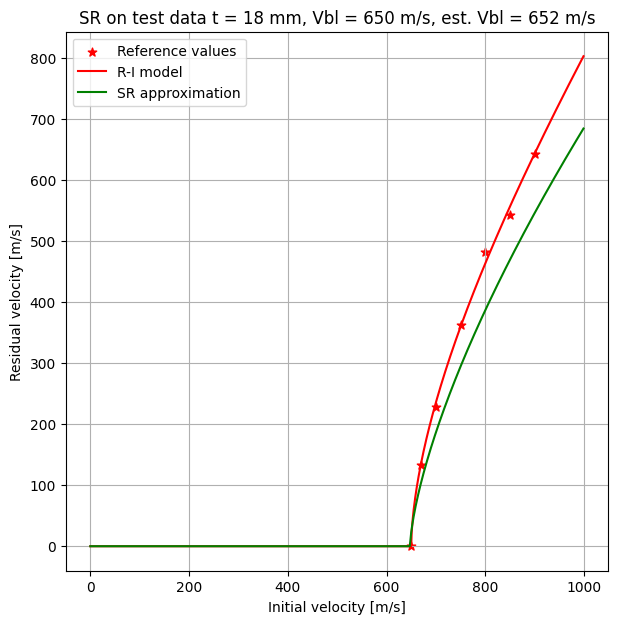

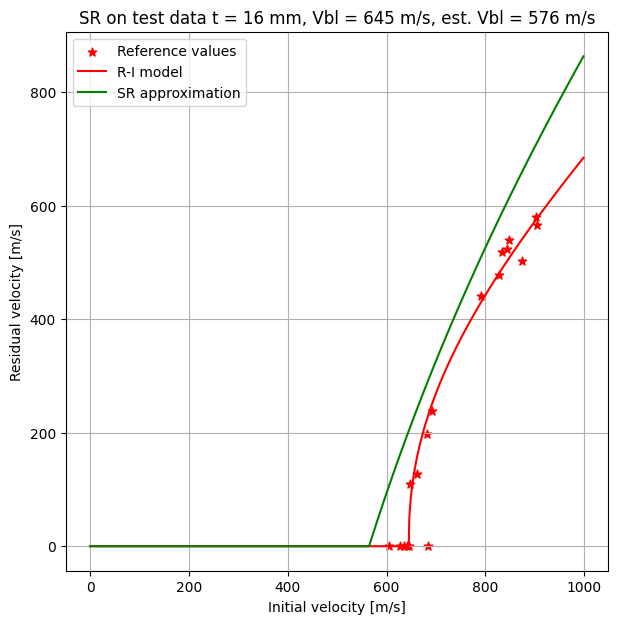

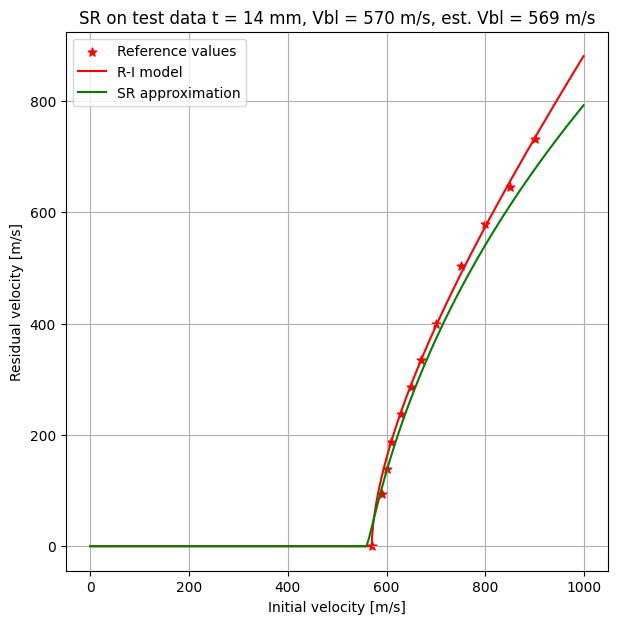

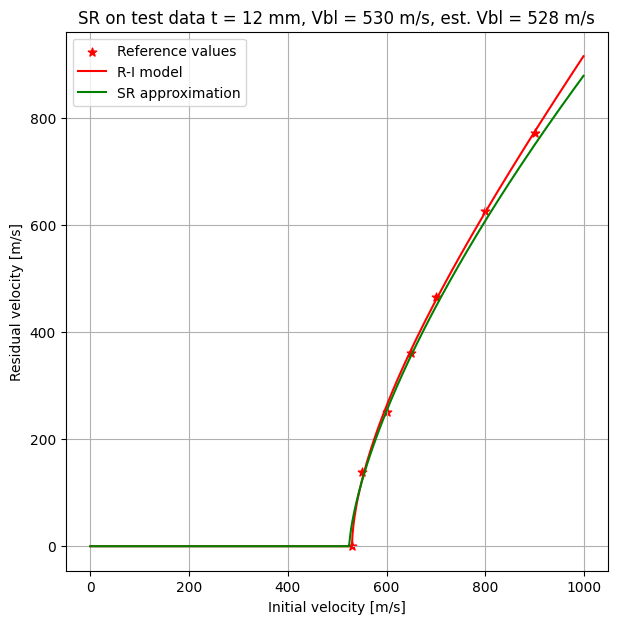

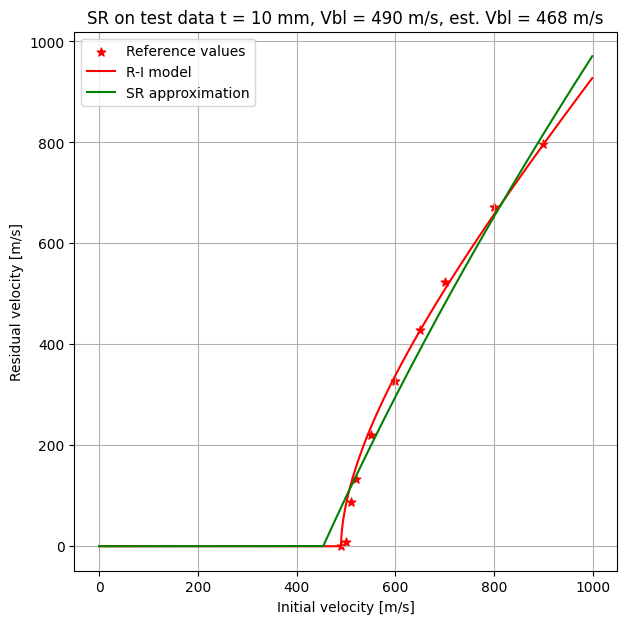

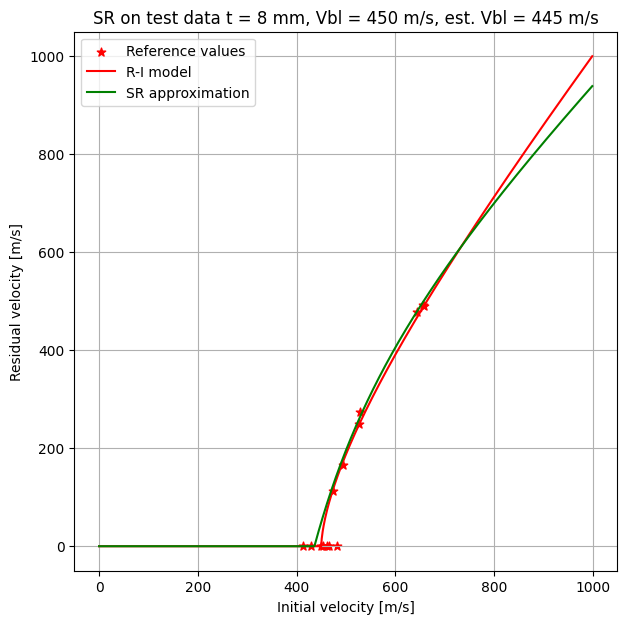

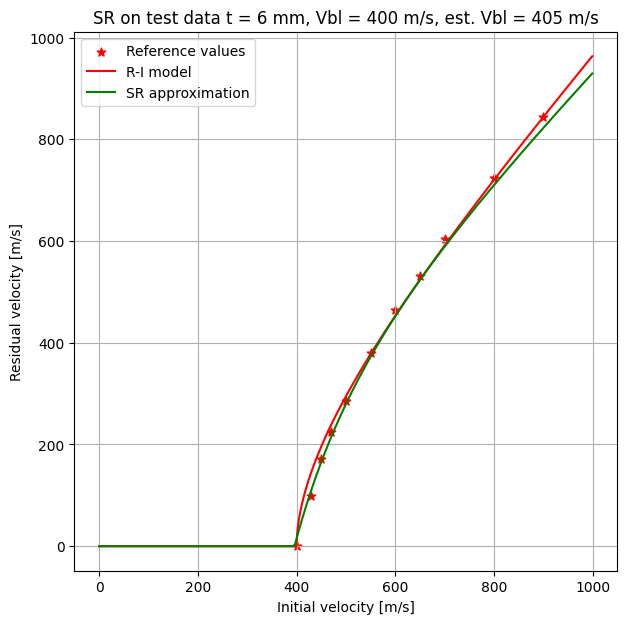

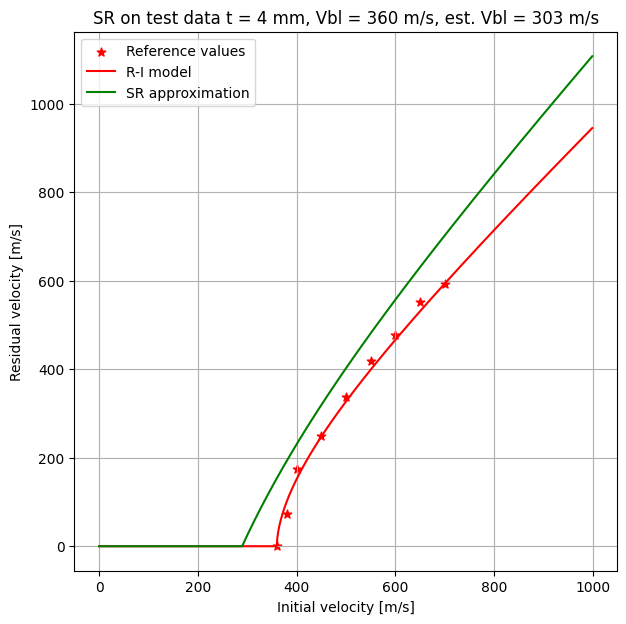

In [9]:
list_vr = []
list_vr_est = []
list_vbl = []
list_vbl_est = []

for t in wspolczynniki_list:
    fig, ax = plt.subplots(figsize=(7, 7))
    (p, a, vbl) = get_params_for_thickness(t)

    id_color = 0
    wsp = wspolczynniki[wspolczynniki[:,3] == t]
    dd = dane[dane[:,2] == t]
    print('t' + str(wsp))
    #print(dd)
    vbl_ = wsp[0, 0]
    aa_ = wsp[0, 1]
    pp_ = wsp[0, 2]
    #vi_ = make_sequence(0, 1000, 100)
    vi_ = np.arange(0, 1000, 1)
    vir_ = Vr(vi_, aa_, pp_, vbl_)


    ax.scatter(dd[:,0], dd[:,1], c=color_list[id_color], label='Reference values', marker=markers[id_color], s=40)
    #plt.plot(vi, vir, c=color_list[id_color], ls='-', label='RL,Vbl=%5.0f m/s, a=%5.2f, p=%5.1f' % tuple([vbl, aa,pp]))
    ax.plot(vi_, vir_, c=color_list[id_color], ls='-', label='R-I model')

    vr_list = []
    for id_t in range(vi_.shape[0]):
        #vr_list.append(vr_(vi_[id_t], t, p, a, vbl))
        vr_list.append(vr_vt(vi_[id_t], t))

    list_vr.append(vir_)
    list_vr_est.append(np.array(vr_list))
    list_vbl.append(vbl_)
    #list_vbl_est.append(vbl(t))

    vbl_exp = find_B_bl(np.array(vr_list), vi_)
    list_vbl_est.append(vbl_exp)
    #plt.title("Prediction on test dataset t = " + str(int(t)) + " mm" + ", Vbl = " + str(int(vbl_)) + ", estimated Vbl = " + str(int(vbl_exp)))
    plt.title("SR on test data t = " + str(int(t)) + " mm" + ", Vbl = " + str(int(vbl_)) + " m/s, est. Vbl = " + str(int(vbl_exp)) + " m/s")

    #plt.title("Prediction on test dataset t = " + str(int(t)) + " mm" + ", Vbl = " + str(int(vbl_)) + ", estimated Vbl = XXX")
    ax.plot(vi_, vr_list, c=color_list[id_color + 1], ls='-', label='SR approximation')

    plt.xlabel('Initial velocity [m/s]')
    plt.ylabel('Residual velocity [m/s]')

    ax.legend()
    plt.grid()

    #plt.savefig("./figures/test_sr_" + str(round(t,)) + ".eps", dpi=300, format='eps', bbox_inches="tight")



t[[650.           1.18526197   1.69636306  18.        ]]
t[[645.     0.84   2.27  16.  ]]
t[[570.           1.18964452   1.66433168  14.        ]]
t[[530.           1.17723814   1.68443586  12.        ]]
t[[490.           1.1282571    1.74498554  10.        ]]
t[[450.     1.24   1.57   8.  ]]
t[[400.           1.08412729   1.80857956   6.        ]]
t[[360.           1.05086957   1.74480626   4.        ]]


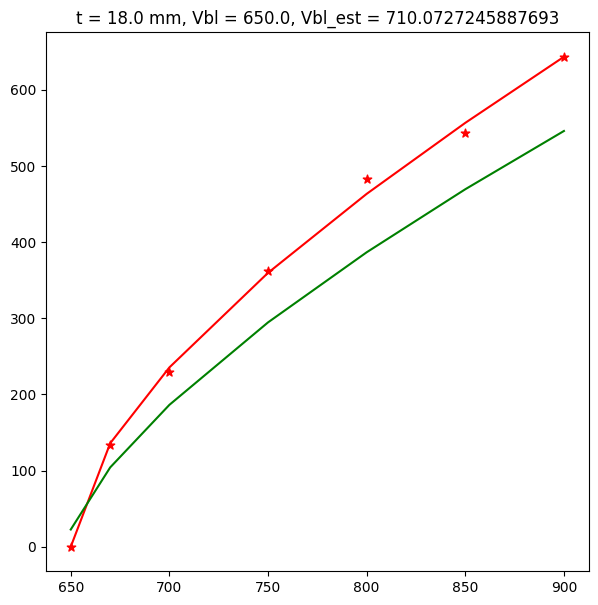

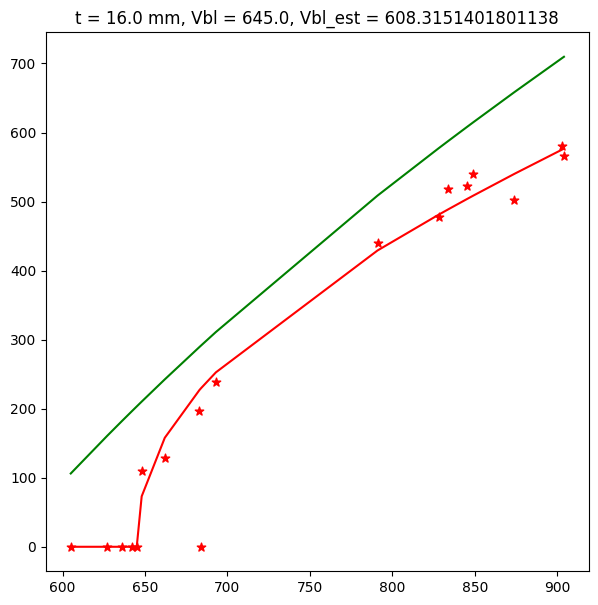

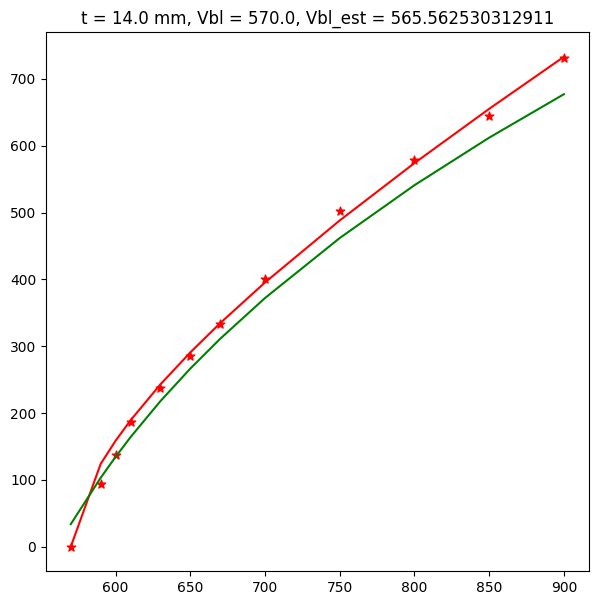

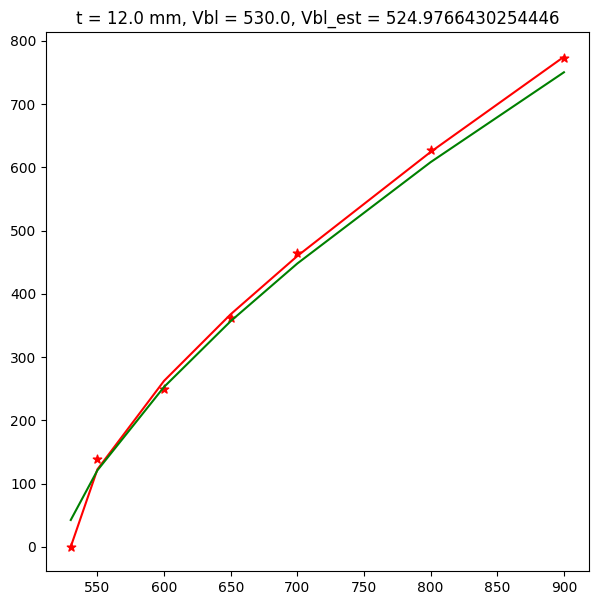

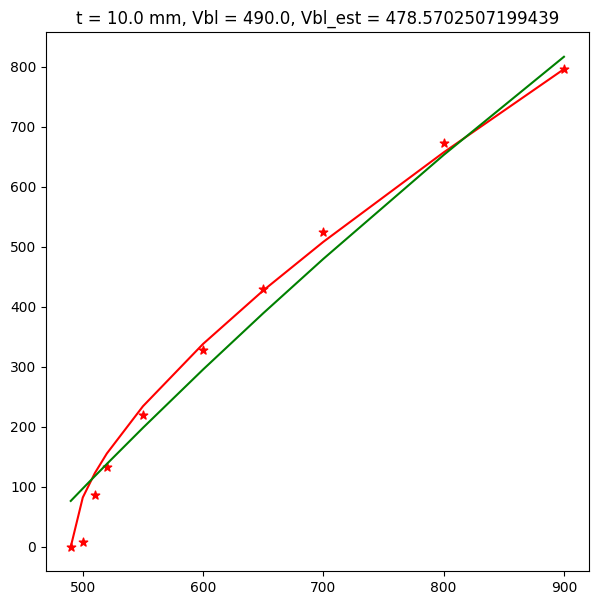

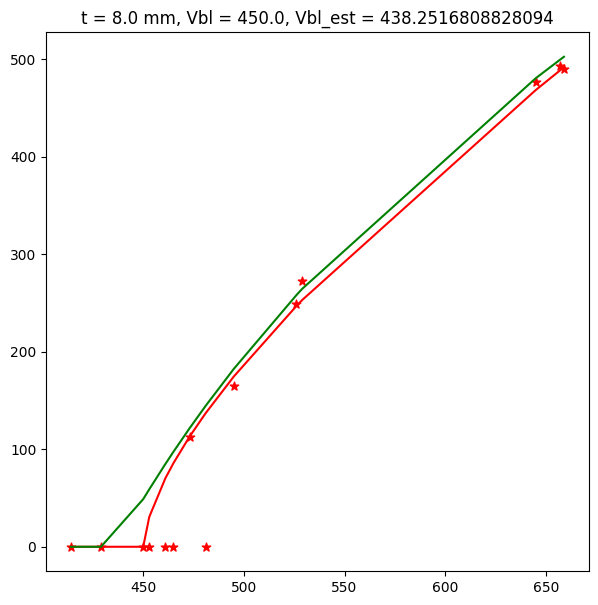

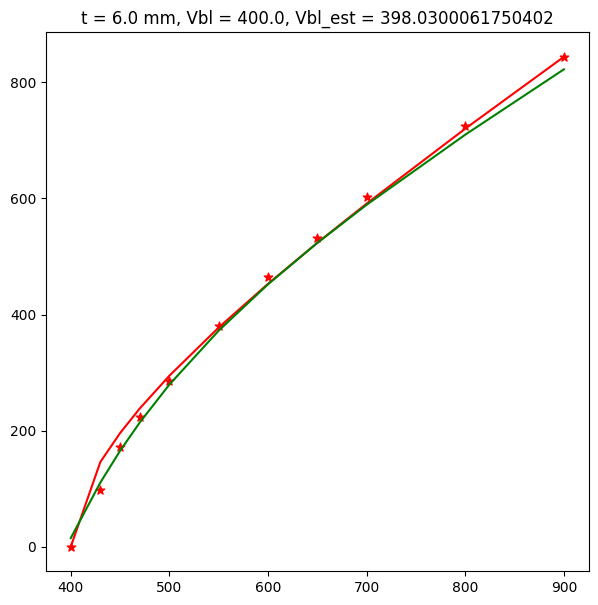

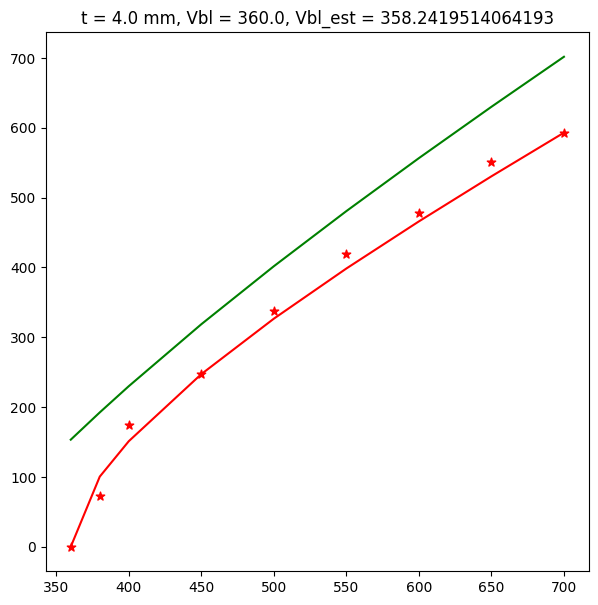

In [10]:
list_vr = []
list_vr_est = []
list_vbl = []
#list_vbl_est = []

for t in wspolczynniki_list:
    plt.subplots(figsize=(7, 7))
    (p, a, vbl) = get_params_for_thickness(t)

    id_color = 0
    wsp = wspolczynniki[wspolczynniki[:,3] == t]
    dd = dane[dane[:,2] == t]
    print('t' + str(wsp))
    #print(dd)
    vbl_ = wsp[0, 0]
    aa_ = wsp[0, 1]
    pp_ = wsp[0, 2]
    #vi_ = make_sequence(0, 1000, 100)
    vi_ = dd[:,0]
    vir_ = Vr(vi_, aa_, pp_, vbl_)


    plt.scatter(dd[:,0], dd[:,1], c=color_list[id_color], label=str(t) + ' mm', marker=markers[id_color], s=40)
    #plt.plot(vi, vir, c=color_list[id_color], ls='-', label='RL,Vbl=%5.0f m/s, a=%5.2f, p=%5.1f' % tuple([vbl, aa,pp]))
    plt.plot(vi_, vir_, c=color_list[id_color], ls='-')

    vr_list = []
    for id_t in range(vi_.shape[0]):
        vr_list.append(vr_vt(vi_[id_t], t))
        #vr_list.append(vr_(vi_[id_t], t, p, a, vbl))

    list_vr.append(vir_)
    list_vr_est.append(np.array(vr_list))
    list_vbl.append(vbl_)
    #list_vbl_est.append(vbl(t))

    plt.title("t = " + str(t) + " mm" + ", Vbl = " + str(vbl_) + ", Vbl_est = " + str(vbl(t)))
    plt.plot(vi_, vr_list, c=color_list[id_color + 1], ls='-')
    #plt.savefig("./figures/test" + str(round(t,)) + ".eps", dpi=300, format='eps', bbox_inches="tight")

import pickle
with open('errors_for_wilcoxon/sr_vanilla.pkl', 'wb') as file:
    pickle.dump((list_vr, list_vr_est, list_vbl, list_vbl_est), file)

In [10]:
t = 8
dd = dane[dane[:,2] == t]
dd[:,0]

array([659., 657., 645., 529., 526., 495., 481., 473., 465., 461., 453.,
       450., 429., 414.])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


"\nif save_flile is not None:\n        plt.savefig(save_flile, format='eps')\nplt.show()\n"

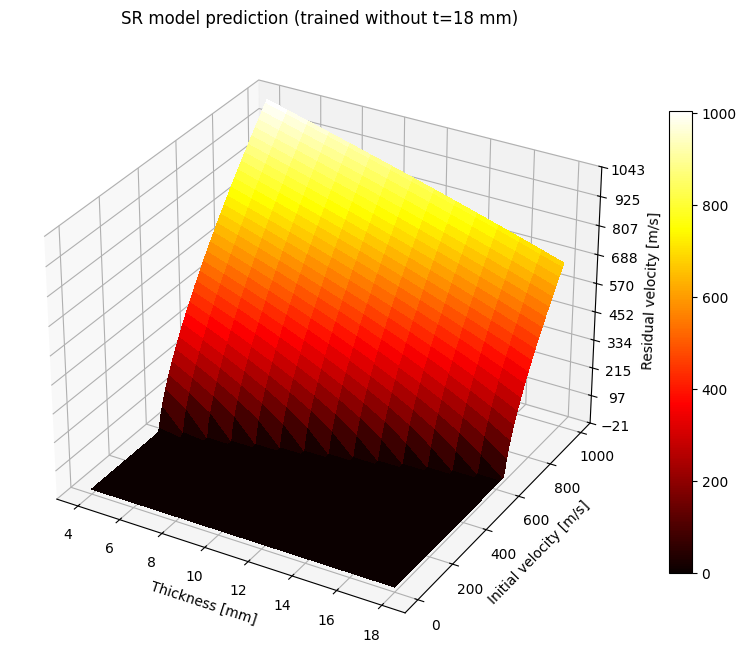

In [27]:
##############################
# Visualization 3d
from matplotlib.ticker import LinearLocator
tt = 18
"""
(p, a, vbl) = get_params_for_thickness(16)
#(v^p(t) - vbl(t)^p(t))^(1/p(t))*a(t)
def vr_(v, t, p, a, vbl):
    part1 = math.pow(v,p(t)) - math.pow(vbl(t),p(t))
    if part1 > 0:
        return math.pow(part1, 1/p(t)) * a(t)
    else:
        return 0
"""
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 10))
ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.0f}')
plt.title('SR model prediction (trained without t=' + str(int(tt)) + ' mm)')
# Add a color bar which maps values to colors.

v_help = np.arange(0, 1000, 10)
t_help = np.arange(4, 19, 1)
v_help, t_help = np.meshgrid(v_help, t_help)
z = np.zeros(v_help.shape)
for x_id in range(z.shape[0]):
    for y_id in range(z.shape[1]):
        #z[x_id, y_id] = vr_(v_help[x_id, y_id], t_help[x_id, y_id], p, a, vbl)
        z[x_id, y_id] = vr_vt_t0(v_help[x_id, y_id], t_help[x_id, y_id], tt)

ax.set(xlabel=('Thickness [mm]'), ylabel=('Initial velocity [m/s]'), zlabel=('Residual velocity [m/s]'))
# viridis, inferno
surf = ax.plot_surface(t_help, v_help, z, cmap='hot', linewidth=0, antialiased=False)
#ax.view_init(0, 10)
fig.colorbar(surf, shrink=0.6, location='right')
plt.savefig("./figures/sr_" + str((int(tt))) + "_surf.eps", format='eps', bbox_inches='tight')
"""
if save_flile is not None:
        plt.savefig(save_flile, format='eps')
plt.show()
"""

In [11]:
def rmse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs(y_true - y_pred))

def r2_score(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    ss_res = np.sum((y_true - y_pred) ** 2)            # suma kwadratów reszt
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)   # całkowita wariancja

    return 1 - ss_res / ss_tot

def relative_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    eps = 1e-12
    return np.abs(y_true - y_pred) / (np.abs(y_true) + eps)



In [12]:

rmse_list = []
mae_list = []
r2_list = []
id_list = 0

eps = 0.000001

for id_list in range(len(list_vr)):
    id_arr = 0
    while list_vr[id_list][id_arr] < eps and list_vr_est[id_list][id_arr] < eps and id_arr < list_vr[id_list].shape[0]:
            id_arr += 1

    rmse_list.append(rmse(list_vr[id_list][id_arr:list_vr[id_list].shape[0]], list_vr_est[id_list][id_arr:list_vr[id_list].shape[0]]))
    mae_list.append(mae(list_vr[id_list][id_arr:list_vr[id_list].shape[0]], list_vr_est[id_list][id_arr:list_vr[id_list].shape[0]]))
    r2_list.append(r2_score(list_vr[id_list][id_arr:list_vr[id_list].shape[0]], list_vr_est[id_list][id_arr:list_vr[id_list].shape[0]]))

print("RMSE = " + str(np.round(np.mean(rmse_list),3)) + " ± " + str(np.round(np.std(rmse_list),3)))
print("MAE = " + str(np.round(np.mean(mae_list),3)) + " ± " + str(np.round(np.std(mae_list),3)))
print("R2 = " + str(np.round(np.mean(r2_list),3)) + " ± " + str(np.round(np.std(r2_list),3)))

re_vbl = relative_error(list_vbl, list_vbl_est)
rmse_vbl = rmse(list_vbl, list_vbl_est)

print("RE vbl = " + str(np.round(np.mean(re_vbl),3)) + " ± " + str(np.round(np.std(re_vbl),3)))
print("RMSE vbl = " + str(np.round(rmse(list_vbl, list_vbl_est),3)))
print("MAE vbl = " + str(np.round(mae(list_vbl, list_vbl_est),3)))
print("R2 vbl = " + str(np.round(r2_score(list_vbl, list_vbl_est),3)))

RMSE = 51.656 ± 38.218
MAE = 47.071 ± 37.509
R2 = 0.908 ± 0.116
RE vbl = 0.043 ± 0.055
RMSE vbl = 32.697
MAE vbl = 20.375
R2 vbl = 0.894


In [27]:
list_vbl_est

[np.int64(652),
 np.int64(576),
 np.int64(569),
 np.int64(528),
 np.int64(468),
 np.int64(445),
 np.int64(405),
 np.int64(303)]

In [78]:
ssss = 7
print(list_vr[ssss])
print(list_vr_est[ssss])
print(rmse(list_vr[ssss], list_vr_est[ssss]))

[592.99999975 530.48220571 465.92453405 398.47649405 326.62597038
 247.21987717 151.18223175 100.47168884   0.        ]
[635.77930514 564.91086349 492.00099676 416.24334141 336.23142261
 249.11044024 147.04588983  95.91485994  18.94466532]
22.3697651067227


In [91]:
def calculate_help():
    list_vr = []
    list_vr_est = []
    list_vbl = []
    list_vbl_est = []

    for t in wspolczynniki_list:
        #plt.subplots(figsize=(7, 7))
        (p, a, vbl) = get_params_for_thickness(t)

        id_color = 0
        wsp = wspolczynniki[wspolczynniki[:,3] == t]
        dd = dane[dane[:,2] == t]
        print('t' + str(wsp))
        #print(dd)
        vbl_ = wsp[0, 0]
        aa_ = wsp[0, 1]
        pp_ = wsp[0, 2]
        vi_ = make_sequence(0, 1000, 100)
        vir_ = Vr(vi_, aa_, pp_, vbl_)


        #plt.scatter(dd[:,0], dd[:,1], c=color_list[id_color], label=str(t) + ' mm', marker=markers[id_color], s=40)
        #plt.plot(vi, vir, c=color_list[id_color], ls='-', label='RL,Vbl=%5.0f m/s, a=%5.2f, p=%5.1f' % tuple([vbl, aa,pp]))
        #plt.plot(vi_, vir_, c=color_list[id_color], ls='-')

        vr_list = []
        for id_t in range(vi_.shape[0]):
            vr_list.append(vr_(vi_[id_t], t, p, a, vbl))

        list_vr.append(vir_)
        list_vr_est.append(np.array(vr_list))
        list_vbl.append(vbl_)
        list_vbl_est.append(vbl(t))

    return (list_vr, list_vr_est, list_vbl, list_vbl_est)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


t[[650.           1.18526197   1.69636306  18.        ]]
t[[645.     0.84   2.27  16.  ]]
t[[570.           1.18964452   1.66433168  14.        ]]
t[[530.           1.17723814   1.68443586  12.        ]]
t[[490.           1.1282571    1.74498554  10.        ]]
t[[450.     1.24   1.57   8.  ]]
t[[400.           1.08412729   1.80857956   6.        ]]
t[[360.           1.05086957   1.74480626   4.        ]]
t[[650.           1.18526197   1.69636306  18.        ]]


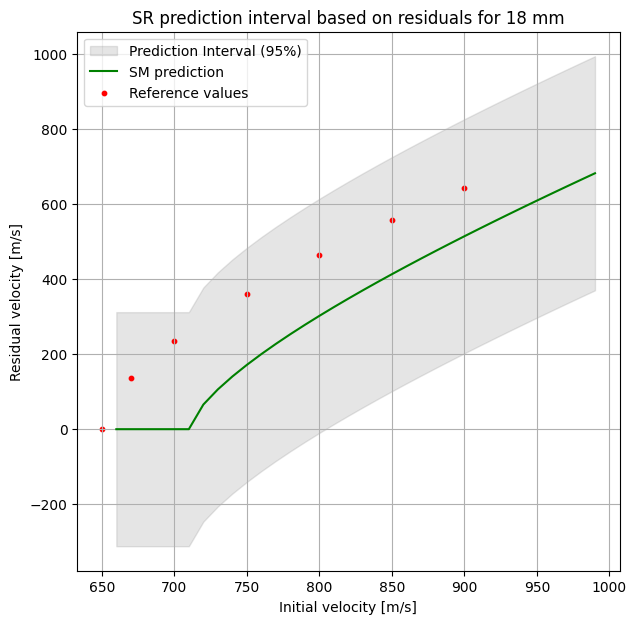

In [110]:
(list_vr_, list_vr_est_, list_vbl_, list_vbl_est_) = calculate_help()

import numpy as np
import matplotlib.pyplot as plt
id_list = 0
id_arr = 0
eps = 0.00001
while list_vr_[id_list][id_arr] < eps and list_vr_est_[id_list][id_arr] < eps and id_arr < list_vr_[id_list].shape[0]:
            id_arr += 1

t = wspolczynniki_list[id_list]

# --- DANE WEJŚCIOWE ---
# vi      - lista wartości X
# vr      - lista wartości rzeczywistych
# vr_exp  - lista błędów (residuów) modelu = vr - y_pred

#vr__ = list_vr[id_list][id_arr:list_vr[id_list].shape[0]]
#vr__est = list_vr_est[id_list][id_arr:list_vr[id_list].shape[0]]
vi = make_sequence(0, 1000, 100)
vi = np.array(vi[id_arr:list_vr_[id_list].shape[0]])
vr = np.array(list_vr_[id_list][id_arr:list_vr_[id_list].shape[0]])
y_pred = np.array(list_vr_est_[id_list][id_arr:list_vr_[id_list].shape[0]])

# --- ODTWORZENIE PREDYKCJI ---
vr_exp = vr - y_pred

# --- OBLICZENIE RMSE ---
rmse = np.sqrt(np.mean(vr_exp**2))

# 95% prediction interval
z = 1.96

from scipy.stats import norm

confidence = 0.95
z = norm.ppf( (1 + confidence) / 2 )

y_lower = y_pred - z * rmse
y_upper = y_pred + z * rmse

# --- WYKRES ---
plt.figure(figsize=(7, 7))
# Prediction Interval
plt.fill_between(vi, y_lower, y_upper, color="gray", alpha=0.2, label="Prediction Interval (95%)")
# Predykcja
plt.plot(vi, y_pred, color="green", label="SM prediction")
# Punkty rzeczywiste
#plt.scatter(vi, vr, label="R-I model values", color="red", s=10)#, alpha=0.6)
##########################################################################

wsp = wspolczynniki[wspolczynniki[:,3] == t]
dd = dane[dane[:,2] == t]
print('t' + str(wsp))
#print(dd)
vbl_ = wsp[0, 0]
aa_ = wsp[0, 1]
pp_ = wsp[0, 2]
#vi_ = make_sequence(0, 1000, 100)
vi_ = dd[:,0]
vir_ = Vr(vi_, aa_, pp_, vbl_)
plt.scatter(vi_, vir_, label="Reference values", color="red", s=10)#, alpha=0.6)
##########################################################################


plt.xlabel('Initial velocity [m/s]')
plt.ylabel('Residual velocity [m/s]')
plt.title("SR prediction interval based on residuals for " + str(round(t,)) + " mm")
plt.legend()
plt.grid(True)
#plt.show()
plt.savefig("./figures/srpi_" + str(round(t,)) + ".eps", dpi=300, format='eps', bbox_inches="tight")


In [88]:
(list_vr_, list_vr_est_, list_vbl_, list_vbl_est_)

([array([  0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   

In [68]:
vi

array([ 0., 10., 20., 30., 40., 50., 60., 70., 80.])